In [7]:
# Cell 1 — Load Data

import pandas as pd
import numpy as np
from pathlib import Path

# Load clean monthly panel
data_path = Path('data')
df = pd.read_csv(data_path / 'clean_monthly_panel.csv', parse_dates=['date'])

# Sort by date and stock
df = df.sort_values(['date', 'permno']).reset_index(drop=True)

# Check
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique stocks: {df['permno'].nunique()}")
print(f"Unique months: {df['date'].nunique()}")
print(f"\nCrisis months (market vol > 30%): {df.groupby('date')['high_vol_regime'].first().sum()}")

Shape: (1913116, 18)
Date range: 1990-01-31 00:00:00 to 2023-12-31 00:00:00
Unique stocks: 18080
Unique months: 408

Crisis months (market vol > 30%): 24


In [8]:
# Cell 2 — Monthly Stock Selection (Benchmark)

# For each month, select the 500 stocks with the lowest realized vol
# Uses real_vol_ann_lag1 (last month's vol) to avoid lookahead bias

def select_benchmark_portfolio(df, n_stocks=500):
    portfolios = []
    
    for date, month_df in df.groupby('date'):
        # Drop stocks with missing lagged vol (e.g. first month)
        available = month_df.dropna(subset=['real_vol_ann_lag1'])
        
        # Need at least 500 stocks available
        if len(available) < n_stocks:
            continue
        
        # Select 500 lowest vol stocks
        selected = available.nsmallest(n_stocks, 'real_vol_ann_lag1').copy()
        selected['date'] = date
        selected['weight'] = 1 / n_stocks  # equal weight
        portfolios.append(selected)
    
    return pd.concat(portfolios, ignore_index=True)

benchmark = select_benchmark_portfolio(df)

print(f"Benchmark shape: {benchmark.shape}")
print(f"Months covered: {benchmark['date'].nunique()}")
print(f"Stocks per month: {benchmark.groupby('date')['permno'].count().mean():.0f}")
print(f"\nAverage selected vol: {benchmark['real_vol_ann_lag1'].mean():.4f}")
print(f"Average market vol: {df.groupby('date')['mkt_vol_ann'].first().mean():.4f}")

Benchmark shape: (203500, 19)
Months covered: 407
Stocks per month: 500

Average selected vol: 0.0344
Average market vol: 0.1464


In [9]:
# Cell 3 (FIXED) — Calculate Net Revenue using actual returns

# Capital cost rate depends on regime
benchmark['capital_cost_rate'] = np.where(
    benchmark['high_vol_regime'] == True, 0.30, 0.15
)

# Use ACTUAL monthly return instead of fixed 5%/12
benchmark['gross_return'] = benchmark['ret']

# Capital cost based on lagged vol (known at start of month)
benchmark['capital_cost'] = (benchmark['capital_cost_rate'] 
                              * benchmark['real_vol_ann_lag1'] / 12)

# Net revenue per stock per month
benchmark['net_revenue'] = benchmark['gross_return'] - benchmark['capital_cost']

# Aggregate to portfolio level
monthly_results = benchmark.groupby('date').agg(
    avg_net_revenue=('net_revenue', 'mean'),
    avg_gross_return=('gross_return', 'mean'),
    avg_vol=('real_vol_ann_lag1', 'mean'),
    high_vol_regime=('high_vol_regime', 'first'),
    market_vol=('mkt_vol_ann', 'first')
).reset_index()

# Cumulative net revenue
monthly_results['cumulative_net_revenue'] = (
    (1 + monthly_results['avg_net_revenue']).cumprod()
)

print(f"Average monthly net revenue: {monthly_results['avg_net_revenue'].mean():.4%}")
print(f"Average monthly gross return: {monthly_results['avg_gross_return'].mean():.4%}")
print(f"Std monthly net revenue: {monthly_results['avg_net_revenue'].std():.4%}")
sharpe = (monthly_results['avg_net_revenue'].mean() / 
          monthly_results['avg_net_revenue'].std()) * np.sqrt(12)
print(f"Sharpe ratio: {sharpe:.4f}")

Average monthly net revenue: 1.0300%
Average monthly gross return: 1.0778%
Std monthly net revenue: 2.9579%
Sharpe ratio: 1.2063


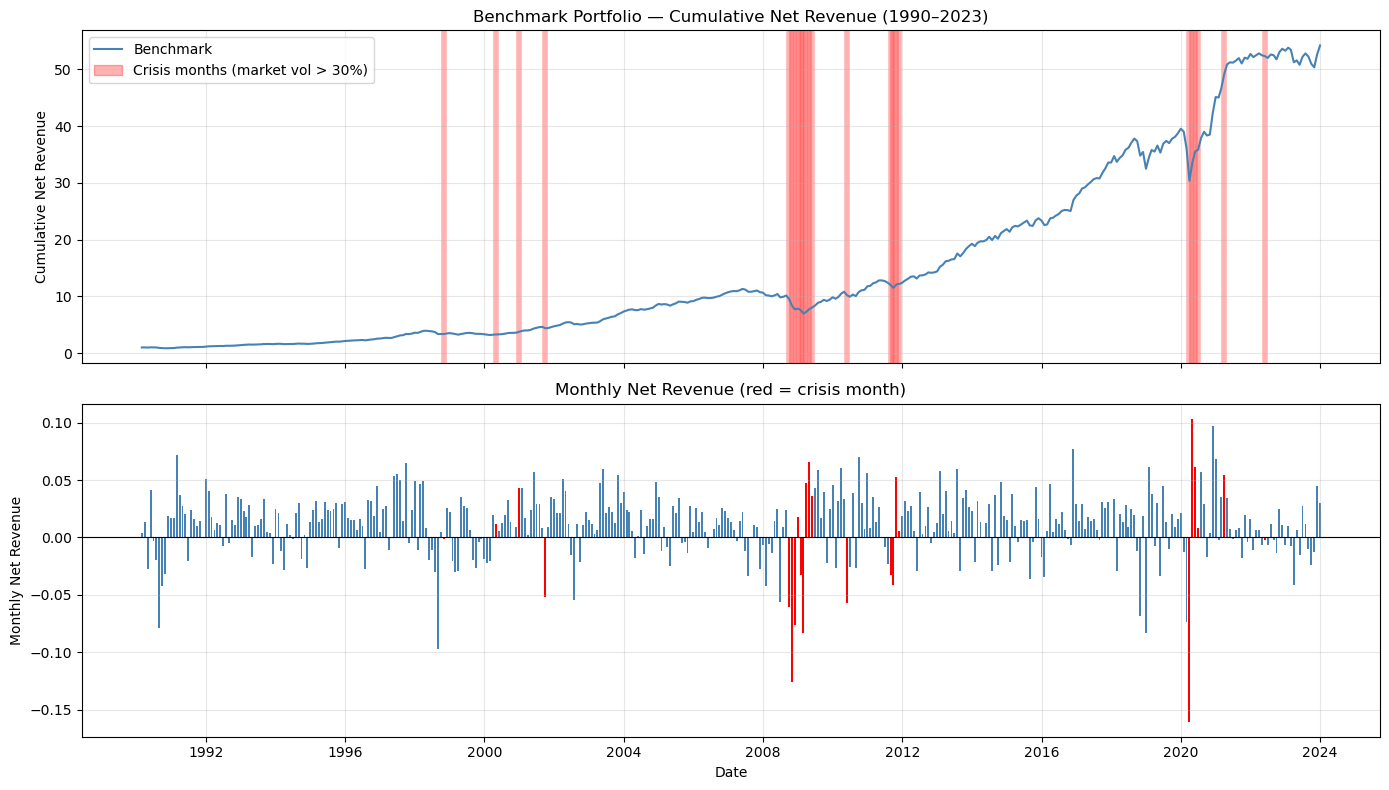

Plot saved to data/benchmark_performance.png


In [10]:
# Cell 4 — Plot Benchmark Performance

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Plot 1: Cumulative net revenue ---
ax1.plot(monthly_results['date'], 
         monthly_results['cumulative_net_revenue'], 
         color='steelblue', linewidth=1.5, label='Benchmark')

# Shade crisis months
for _, row in monthly_results[monthly_results['high_vol_regime']].iterrows():
    ax1.axvspan(row['date'], row['date'], alpha=0.3, color='red', linewidth=4)

ax1.set_ylabel('Cumulative Net Revenue')
ax1.set_title('Benchmark Portfolio — Cumulative Net Revenue (1990–2023)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add crisis patch to legend
crisis_patch = mpatches.Patch(color='red', alpha=0.3, label='Crisis months (market vol > 30%)')
ax1.legend(handles=[plt.Line2D([0], [0], color='steelblue', linewidth=1.5, 
                                label='Benchmark'), crisis_patch])

# --- Plot 2: Monthly net revenue ---
colors = ['red' if x else 'steelblue' for x in monthly_results['high_vol_regime']]
ax2.bar(monthly_results['date'], 
        monthly_results['avg_net_revenue'], 
        color=colors, width=20)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylabel('Monthly Net Revenue')
ax2.set_xlabel('Date')
ax2.set_title('Monthly Net Revenue (red = crisis month)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_path / 'benchmark_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to data/benchmark_performance.png")

In [14]:
# Cell 5 — Summary Statistics (Benchmark)

import pandas as pd
import numpy as np

# ── Full period stats ──────────────────────────────────────
mean_monthly   = monthly_results['avg_net_revenue'].mean()
std_monthly    = monthly_results['avg_net_revenue'].std()
sharpe         = (mean_monthly / std_monthly) * np.sqrt(12)

best_month  = monthly_results.loc[monthly_results['avg_net_revenue'].idxmax()]
worst_month = monthly_results.loc[monthly_results['avg_net_revenue'].idxmin()]

normal = monthly_results[~monthly_results['high_vol_regime']]
crisis = monthly_results[monthly_results['high_vol_regime']]

# ── OOS period (2010-2023) for later comparison ───────────
oos = monthly_results[monthly_results['date'] >= '2010-01-01']
oos_mean   = oos['avg_net_revenue'].mean()
oos_std    = oos['avg_net_revenue'].std()
oos_sharpe = (oos_mean / oos_std) * np.sqrt(12)

# ── Print results ──────────────────────────────────────────
print("=" * 55)
print("BENCHMARK PORTFOLIO — SUMMARY STATISTICS")
print("=" * 55)

print(f"\n--- FULL PERIOD (1990–2023) ---")
print(f"Months:                    {monthly_results['date'].nunique()}")
print(f"Avg monthly net revenue:   {mean_monthly:.4%}")
print(f"Avg annual net revenue:    {mean_monthly*12:.4%}")
print(f"Std monthly net revenue:   {std_monthly:.4%}")
print(f"Sharpe ratio (annualized): {sharpe:.4f}")
print(f"Best month:  {best_month['date'].strftime('%Y-%m')} ({best_month['avg_net_revenue']:.4%})")
print(f"Worst month: {worst_month['date'].strftime('%Y-%m')} ({worst_month['avg_net_revenue']:.4%})")

print(f"\n--- CRISIS VS NORMAL ---")
print(f"Normal months ({len(normal):>3}):  avg {normal['avg_net_revenue'].mean():.4%}/month")
print(f"Crisis months ({len(crisis):>3}):   avg {crisis['avg_net_revenue'].mean():.4%}/month")
print(f"Crisis performance drop:   {(1 - crisis['avg_net_revenue'].mean()/normal['avg_net_revenue'].mean()):.1%}")

print(f"\n--- OOS PERIOD (2010–2023) ---")
print(f"Months:                    {len(oos)}")
print(f"Avg monthly net revenue:   {oos_mean:.4%}")
print(f"Avg annual net revenue:    {oos_mean*12:.4%}")
print(f"Sharpe ratio (annualized): {oos_sharpe:.4f}")

print(f"\n--- NOTE ON STATISTICAL VALIDATION ---")
print(f"The benchmark uses lagged realized volatility as a")
print(f"naive vol forecast (real_vol_ann_lag1). ML models")
print(f"are evaluated against this baseline — a positive")
print(f"OOS R² vs lagged vol indicates genuine forecasting")
print(f"improvement beyond naive persistence.")
print("=" * 55)

# ── Save benchmark results for later comparison ────────────
benchmark_summary = {
    'full_period_annual_net_revenue' : mean_monthly * 12,
    'full_period_sharpe'             : sharpe,
    'full_period_worst_month'        : worst_month['avg_net_revenue'],
    'full_period_best_month'         : best_month['avg_net_revenue'],
    'crisis_avg_net_revenue'         : crisis['avg_net_revenue'].mean(),
    'normal_avg_net_revenue'         : normal['avg_net_revenue'].mean(),
    'oos_annual_net_revenue'         : oos_mean * 12,
    'oos_sharpe'                     : oos_sharpe,
}

print("\nBenchmark summary saved for model comparison ✅")
print(benchmark_summary)

BENCHMARK PORTFOLIO — SUMMARY STATISTICS

--- FULL PERIOD (1990–2023) ---
Months:                    407
Avg monthly net revenue:   1.0300%
Avg annual net revenue:    12.3606%
Std monthly net revenue:   2.9579%
Sharpe ratio (annualized): 1.2063
Best month:  2020-04 (10.3355%)
Worst month: 2020-03 (-16.0244%)

--- CRISIS VS NORMAL ---
Normal months (383):  avg 1.1515%/month
Crisis months ( 24):   avg -0.9081%/month
Crisis performance drop:   178.9%

--- OOS PERIOD (2010–2023) ---
Months:                    168
Avg monthly net revenue:   1.0709%
Avg annual net revenue:    12.8505%
Sharpe ratio (annualized): 1.1696

--- NOTE ON STATISTICAL VALIDATION ---
The benchmark uses lagged realized volatility as a
naive vol forecast (real_vol_ann_lag1). ML models
are evaluated against this baseline — a positive
OOS R² vs lagged vol indicates genuine forecasting
improvement beyond naive persistence.

Benchmark summary saved for model comparison ✅
{'full_period_annual_net_revenue': np.float64(0.12360